In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

plt.style.use("default")

df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")
df = df.drop(columns=["Unnamed: 0"])
df = df.dropna(subset=["Division Name", "Department Name", "Class Name"])
df["Review Text"] = df["Review Text"].fillna("")
df["Title"] = df["Title"].fillna("")

df["review_length"] = df["Review Text"].str.len()

In [43]:
fig = px.histogram(df, x="Rating", nbins=5,
                   title="Distribution of Customer Ratings")
fig.show()

generally positive customer sentiment

In [44]:
rec_rate = df.groupby("Rating")["Recommended IND"].mean().reset_index()

fig = px.line(rec_rate, x="Rating", y="Recommended IND",
              markers=True,
              title="Probability of Recommendation by Rating")
fig.show()

Recommendation increases sharply with rating → strong alignment between satisfaction and action

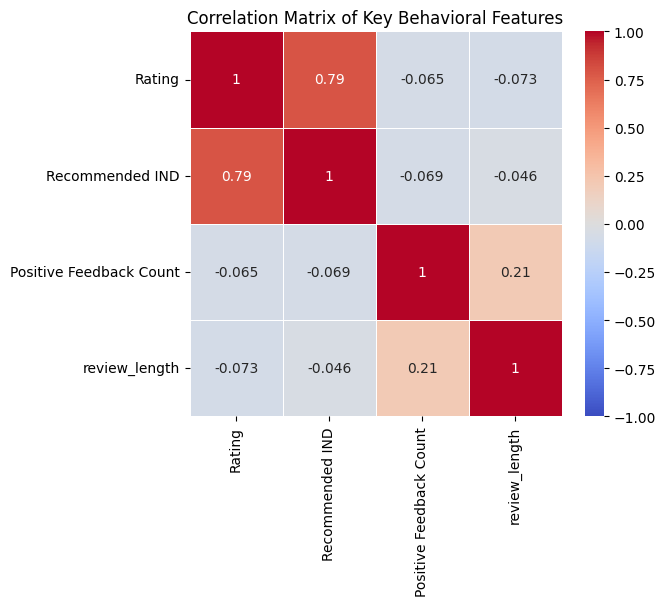

In [45]:
cols = ["Rating", "Recommended IND", "Positive Feedback Count", "review_length"]

corr = df[cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)

plt.title("Correlation Matrix of Key Behavioral Features")
plt.show()

Review length shows no significant correlation with Rating or Recommendation status, suggesting that customers’ ratings and recommendation decisions are independent of how much they write.

A weak positive relationship between review length and Positive Feedback Count indicates that longer reviews may receive slightly more engagement, possibly because they contain more detailed opinions or are more noticeable to other users. However, this effect is weak and not strongly predictive.

In [46]:
dept = df.groupby("Department Name")["Rating"].mean().reset_index()

fig = px.bar(dept, x="Department Name", y="Rating",
             title="Average Rating by Department")
fig.show()

In [47]:
fig = px.box(
    df,
    x="Department Name",
    y="Rating",
    title="Distribution of Ratings by Department",
    points="outliers"  # shows extreme values
)

fig.show()

Customer satisfaction is relatively consistent across most departments, as indicated by similar rating distributions and central tendencies. However, the Trend department deviates from this pattern, exhibiting a slightly lower average rating and a noticeably higher variance. This suggests that trend-oriented products generate more polarized customer responses, likely due to their experimental or fashion-forward nature.

In [48]:
df["is_trend"] = (df["Department Name"] == "Trend").astype(int)

In [49]:
fig = px.box(
    df,
    x="is_trend",
    y="Rating",
    title="Ratings: Trend vs Non-Trend Products"
)

fig.show()

When grouping all non-trend departments together, the distinction becomes clearer: trend products show lower average ratings and higher variability, reinforcing the idea that they produce more polarized customer responses.

In [50]:
fig = px.box(df, x="Rating", y="review_length",
             title="Review Length by Rating")
fig.show()

In [51]:
summary = df.groupby("is_trend")["review_length"].mean().reset_index()

fig = px.bar(
    summary,
    x="is_trend",
    y="review_length",
    title="Average Review Length: Trend vs Non-Trend"
)

fig.show()

In [52]:
fig = px.box(
    df,
    x="is_trend",
    y="review_length",
    title="Review Length: Trend vs Non-Trend Products",
    labels={"is_trend": "Is Trend (1 = Trend, 0 = Non-Trend)"}
)

fig.show()

In [53]:
df["log_feedback"] = np.log1p(df["Positive Feedback Count"])

fig = px.box(
    df,
    x="is_trend",
    y="log_feedback",
    title="Log(Positive Feedback Count): Trend vs Non-Trend Products",
    labels={"is_trend": "Is Trend (1 = Trend, 0 = Non-Trend)"}
)

fig.show()

In [54]:
summary = df.groupby("is_trend")["log_feedback"].mean().reset_index()

fig = px.bar(
    summary,
    x="is_trend",
    y="log_feedback",
    title="Average Log(Positive Feedback Count): Trend vs Non-Trend"
)

fig.show()

Trend products generate more detailed feedback, suggesting stronger emotional reactions (positive or negative).